# Fake News Detection using Machine Learning and NLP

**Short description:**
This project uses Natural Language Processing (NLP) and Machine Learning techniques to classify news articles as Fake or Real.

## Step 1 — Import Required Libraries

**Short description:**
Import all required libraries for data handling, visualization, NLP preprocessing, and machine learning.

In [143]:
import pandas as pd                  # For data handling and analysis
import numpy as np                   # For numerical operations
import matplotlib.pyplot as plt      # For plotting graphs
import seaborn as sns                # For better data visualizations

# Improves graph appearance
sns.set_style("whitegrid")

## Step 2 — Upload and Load Dataset

### 2.1 Load Fake.csv

**Short description:**
Load fake news dataset into a pandas dataframe.

### 2.2 Load True.csv

**Short description:**
Load real news dataset into a pandas dataframe.

In [144]:
# Load fake news dataset
fake_df = pd.read_csv("Fake.csv")

# Load real news dataset
true_df = pd.read_csv("True.csv")

## Step 3 — Dataset Inspection

### 3.1 Check Dataset Shape

**Short description:**
Inspect the dimensions of the dataset.

In [145]:
# Shape tells:
# Number of rows = news articles
# Number of columns = features

print("\nShape of Dataset:")
print(fake_df.shape)
print(true_df.shape)


Shape of Dataset:
(23481, 4)
(21417, 4)


### 3.2 Check Column Names

**Short description:**
Verify available features and column names.

In [146]:
# Print all column names
print("\nColumns in Dataset:")
print(fake_df.columns)
print(true_df.columns)


Columns in Dataset:
Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


### 3.3 Display Sample Rows

**Short description:**
Preview dataset records for basic understanding.

In [147]:
print("\nDataset Sample Rows:")
print(fake_df.head())


Dataset Sample Rows:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [148]:
print(true_df.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   


### 3.4 Dataset Information
Short description:
Inspect datatype, non-null values, and memory usage.

In [149]:
# Dataset information:
# Shows datatype, non-null count and memory usage
print("\nDataset Information:")
fake_df.info()
true_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


### 3.5 Check Missing Values

**Short description:**
Identify null or missing values.

In [150]:
# Count missing values in every column

print("\nMissing Values in Dataset:")
print(fake_df.isnull().sum())
print(true_df.isnull().sum())


Missing Values in Dataset:
title      0
text       0
subject    0
date       0
dtype: int64
title      0
text       0
subject    0
date       0
dtype: int64


## Step 4 — Label Encoding

### 4.1 Fake News = 0

**Short description:**
Assign numerical label 0 to fake news articles.

### 4.2 Real News = 1

**Short description:**
Assign numerical label 1 to real news articles.

In [151]:
# ADD LABEL COLUMN

# Fake news = 0
fake_df["label"] = 0

# Real news = 1
true_df["label"] = 1

## Step 5 — Dataset Merging

### 5.1 Merge Fake and True Dataset

**Short description:**
Combine both datasets into a single dataframe.

In [152]:
# MERGE BOTH DATASETS

# Combine fake + real dataset
df = pd.concat(
    [fake_df, true_df],
    axis=0
)

### 5.2 Shuffle Dataset

**Short description:**
Randomly shuffle dataset records to avoid ordering bias.

In [153]:
# Shuffle rows randomly

# Otherwise fake news comes first and real news later

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# Check result
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## Step 6 — Data Cleaning

### 6.1 Select Required Columns

**Short description:**
Keep only relevant features for analysis.

In [154]:
# We only keep columns useful for fake news detection

# title      -> headline of article
# text       -> article content
# category   -> news category (politics, sports, etc.)
# label      -> target variable (fake/real)

# Ignoring:
# date       -> low usefulness for ML model
# source     -> many missing values possible
# author     -> many missing values possible

clean_df = df[
    ["title", "text", "subject", "label"]
].copy()

print("\nSelected Important Columns:")
display(clean_df.head())


Selected Important Columns:


,title,text,subject,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,1


### 6.2 Remove Null Values

**Short description:**
Remove missing entries from dataset.

In [155]:
# Since unnecessary columns are removed, check if missing values still exist

print("\nMissing Values:")
print(clean_df.isnull().sum())


Missing Values:
title      0
text       0
subject    0
label      0
dtype: int64


### 6.3 Remove Duplicate Records

**Short description:**
Remove duplicate articles to improve data quality.

In [156]:
# Remove rows containing missing values
# Reassign dataframe to avoid warning

clean_df = clean_df.dropna()

print("\nMissing Values After Cleaning:")
print(clean_df.isnull().sum())


Missing Values After Cleaning:
title      0
text       0
subject    0
label      0
dtype: int64


### 6.4 Check Class Distribution

**Short description:**
Analyze balance between fake and real news classes.

In [157]:
# Duplicate rows can cause:
# - Data leakage
# - Artificially high accuracy
# - Poor model generalization

duplicate_count = clean_df.duplicated().sum()

print("\nNumber of Duplicate Rows:")
print(duplicate_count)

# Remove duplicate rows
# Reassign dataframe to avoid warning

clean_df = clean_df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(clean_df.shape)


Number of Duplicate Rows:
213

Dataset Shape After Removing Duplicates:
(44685, 4)


### 6.5 Check Class Distribution

**Short description:**  
Analyze the distribution of fake and real news articles to check whether the dataset is balanced or imbalanced.

In [158]:
# Helps determine:
# Is dataset balanced or imbalanced?

print("\nFake vs Real News Count:")
print(clean_df["label"].value_counts())


Fake vs Real News Count:
label
0    23477
1    21208
Name: count, dtype: int64


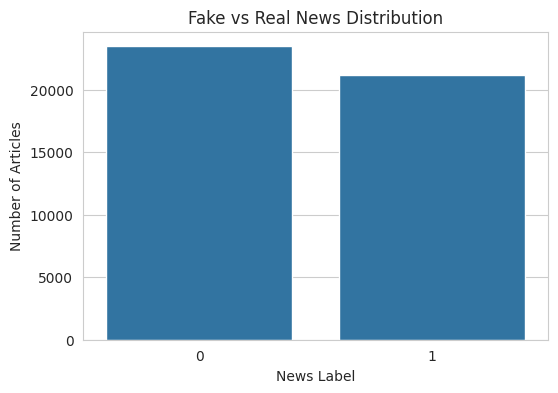

In [159]:
plt.figure(figsize=(6,4))

# Countplot shows frequency of each label
sns.countplot(
    x="label",
    data=clean_df
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("News Label")
plt.ylabel("Number of Articles")

plt.show()

## Step 7 — Text Feature Engineering

### 7.1 Combine title + text + subject
**Short description:**
Merge text-based features into one unified column.

In [160]:
'''We combine:   title + text + category

Why?
- title gives headline context
- text gives detailed information
- category gives domain information

This creates one rich text feature for ML models.'''

clean_df["content"] = (

    clean_df["title"].astype(str)

    + " " +

    clean_df["text"].astype(str)

    + " " +

    clean_df["subject"].astype(str)
)

### 7.2 Display Sample Combined Content
**Short description:**
Verify merged textual feature.

In [161]:
# Display one sample article
print("Sample Combined Content:\n")

print(clean_df["content"].iloc[0])

Sample Combined Content:

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual 

## Step 8 — NLP Preprocessing

In [162]:
# IMPORT REQUIRED LIBRARIES

import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# DOWNLOAD REQUIRED NLTK PACKAGES

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 8.1 Stopword Removal

**Short description:**
Remove frequently occurring words with low semantic value.

In [163]:
''' CREATE STOPWORDS LIST

    Common English words
    Example:
        the, is, a, an, was
'''

stop_words = set(
    stopwords.words("english")
)

### 8.2 Lemmatization

**Short description:**
Convert words into their root/base form.

In [164]:
# INITIALIZE LEMMATIZER

lemmatizer = WordNetLemmatizer()

### 8.3 Lowercase Conversion

**Short description:**
Convert all text to lowercase for consistency.

### 8.4 Punctuation Removal

**Short description:**
Remove punctuation symbols from text.

### 8.5 Tokenization

**Short description:**
Split text into individual words.

### 8.6 Number Removal

**Short description:**
Remove numerical values to reduce unnecessary noise.

### 8.7 Create processed_text Column

**Short description:**
Generate cleaned text for machine learning models.

In [165]:
# CREATE TEXT PREPROCESSING FUNCTION

def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    # Example:
    # hello!!! -> hello
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    # Tokenization
    # Split sentence into words
    words = word_tokenize(text)

    # Empty list to store cleaned words
    cleaned_words = []

    # Process every word
    for word in words:

        # Keep alphabet words only
        # Removes:
        # numbers, symbols
        if word.isalpha():

            # Remove stopwords
            if word not in stop_words:

                # Lemmatization
                word = lemmatizer.lemmatize(word)

                cleaned_words.append(word)

    # Join words back into sentence
    return " ".join(cleaned_words)



### 8.8 Apply NLP Preprocessing
Short description:
Apply cleaning function to content column.

In [166]:
# APPLY NLP PREPROCESSING

print("Applying NLP preprocessing...")

clean_df["processed_text"] = (
    clean_df["content"]
    .apply(preprocess_text)
)

print("Preprocessing completed!")

Applying NLP preprocessing...
Preprocessing completed!


### 8.9 Compare Before vs After
Short description:
Verify preprocessing output.

In [167]:
# DISPLAY BEFORE & AFTER

print("\nORIGINAL TEXT:\n")
print(clean_df["content"].iloc[0][:500])


ORIGINAL TEXT:

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto


In [168]:
print("\nPROCESSED TEXT:\n")
print(clean_df["processed_text"].iloc[0][:500])


PROCESSED TEXT:

ben stein call circuit court committed coup état constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview 


## Step 9 — TF-IDF Vectorization

In [169]:
# TF-IDF converts text into numerical features

from sklearn.feature_extraction.text import TfidfVectorizer

### 9.1 Create TF-IDF Vectorizer

**Short description:**
Initialize TF-IDF feature extraction method.

In [170]:
# Create TF-IDF object

tfidf = TfidfVectorizer(

    # Maximum number of important words
    # to keep as features
    max_features=5000,

    # Ignore extremely common words
    max_df=0.7,

    # Ignore very rare words
    min_df=2
)

print("TF-IDF Vectorizer Created Successfully!")

TF-IDF Vectorizer Created Successfully!


### Understand every parameter

1.  `max_features=5000`

    This means:

    *   Keep only the top 5000 important words.

    Without this:

    *   Dataset could create: `100,000+` features
    *   Very heavy.
    *   Harder training.
    *   Slower notebook.

    So we limit to:

    *   `5000`
    *   Best balance for college project.

2.  `max_df=0.7`

    Meaning:

    *   Ignore words appearing in more than `70%` of articles.

    Example:

    *   Words like:
        *   `said`
        *   `people`
        *   `government`
        *   `news`

    *   may appear too much.

    *   They become less informative.

    So TF-IDF removes overly common words.

3.  `min_df=2`

    Meaning:

    *   Ignore words appearing in only `1` article.

    Example:

    *   Random typo:
        *   `asdfgh`

    *   or rare garbage word.

    *   These don't help learning.

    So we ignore them.

### 9.2 Convert Text into Numerical Features

**Short description:**
Transform processed text into numerical vectors.

### 9.3 Create X and y

**Short description:**
Prepare feature matrix and target labels.

In [171]:
# APPLY TF-IDF TRANSFORMATION

# X = Input Features
# We use processed text for training

X = tfidf.fit_transform(
    clean_df["processed_text"]
)

# y = Target Variable
# label:
# 0 = Fake News
# 1 = Real News

y = clean_df["label"]


# DISPLAY BASIC INFORMATION

print("TF-IDF Transformation Completed Successfully!")

print("\nShape of Feature Matrix (X):")
print(X.shape)

print("\nShape of Labels (y):")
print(y.shape)

TF-IDF Transformation Completed Successfully!

Shape of Feature Matrix (X):
(44685, 5000)

Shape of Labels (y):
(44685,)


## Step 10 — Train-Test Split

### 10.1 Split Dataset into Training and Testing Data

**Short description:**
Split dataset into training and testing sets using an 80–20 ratio.

### 10.2 Verify Shapes

**Short description:**
Check dimensions of training and testing datasets.

In [172]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# 80% for training, 20% for testing
# stratify=y ensures that the proportion of labels is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed Successfully!")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Train-Test Split Completed Successfully!
Shape of X_train: (35748, 5000)
Shape of X_test: (8937, 5000)
Shape of y_train: (35748,)
Shape of y_test: (8937,)


## Step 11 — Save Processed Dataset

**Short description:**  
Save the cleaned and preprocessed dataset for future use and reproducibility.

In [173]:
# Save cleaned dataset for future steps
# index=False prevents extra index column in CSV

clean_df.to_csv(
    "processed_fake_news_dataset.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


### 11.1 Download Processed Dataset

**Short description:**  
Download the processed dataset for backup and future model training.

In [174]:
from google.colab import files

files.download(
    "processed_fake_news_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>